<a href="https://colab.research.google.com/github/Khushibung05/RNN/blob/main/RNN_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

from google.colab import drive

# Mount your Google Drive
drive.mount('/content/drive/')

# Path to the dataset (update if needed)
path = '/content/drive/My Drive/Colab Notebooks/IMDB_Dataset.csv'
# Importing the dataset
df= pd.read_csv(path)
print(df.head())

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


 Text reviews are sequential data because the meaning depends on the order of words, and each word’s interpretation is influenced by previous words.

 Traditional machine learning models struggle because they treat text as independent features (bag-of-words), ignoring word order, context, and dependencies between words.

 RNN is suitable because it processes data sequentially, maintains a hidden memory of previous words, and captures contextual relationships, making it effective for understanding sentiment in text.

In [ ]:
# dataset size
print("Shape:", df.shape)

#Count Positive vs Negative Reviews
print(df['sentiment'].value_counts())

#Display Sample Reviews
print(df.head())

#Calculate Average Review Length
#We measure length in number of words
df['review_length'] = df['review'].apply(lambda x: len(x.split()))
print("Average length:", df['review_length'].mean())

print(df['review_length'].describe())

Shape: (50000, 2)
sentiment
positive    25000
negative    25000
Name: count, dtype: int64
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
Average length: 231.15694
count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: review_length, dtype: float64


**Are reviews balanced?**

 Yes

Positive = 25,000
Negative = 25,000

Dataset is perfectly balanced, so:
No bias toward one class
No need for resampling

**Are reviews long or short?**

Reviews are relatively long

Average length ≈ 200+ words
Some reviews are even longer

Implication:
Need sequence models (like RNN)
Might require padding/truncation

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean'] = df['review'].apply(preprocess)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
#Task 4 — Tokenization (Keras)
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean'])

sequences = tokenizer.texts_to_sequences(df['clean'])

# word index
print(list(tokenizer.word_index.items())[:10])

[('<OOV>', 1), ('movie', 2), ('film', 3), ('one', 4), ('like', 5), ('good', 6), ('even', 7), ('would', 8), ('time', 9), ('really', 10)]


In [ ]:
#Task 5 — Padding
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 200

padded = pad_sequences(sequences, maxlen=max_len)

print(sequences[0])
print(padded[0])

[4, 1809, 941, 57, 397, 3207, 287, 350, 3025, 108, 482, 471, 1, 20, 58, 3097, 3207, 1, 1, 51, 473, 181, 108, 549, 53, 1605, 42, 1, 1, 1, 42, 2358, 1, 1, 1339, 277, 473, 3259, 247, 234, 1, 354, 3207, 1, 241, 1, 1, 2418, 939, 1, 2482, 1247, 1, 422, 4557, 2375, 1081, 1, 2830, 1, 299, 1, 1, 216, 4902, 3549, 422, 237, 1, 1, 1, 1, 4988, 1, 2318, 1, 1, 225, 1, 1, 1, 1, 1, 35, 127, 1, 8, 46, 167, 1173, 42, 551, 92, 160, 155, 436, 2843, 704, 85, 1145, 4165, 2353, 975, 704, 1282, 704, 1, 59, 853, 88, 20, 287, 44, 105, 3097, 1451, 2067, 288, 46, 1422, 175, 1336, 1122, 3207, 89, 1, 216, 1949, 1961, 473, 473, 1, 1, 4784, 1, 2798, 1, 1, 1, 380, 500, 15, 141, 14, 1, 633, 694, 1, 543, 1081, 1, 551, 439, 807, 1860, 1081, 444, 57, 3207, 99, 303, 3602, 3115, 1, 15, 1083, 3862, 392]
[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    4 1809  941   57  397 3207  287  350 3025  108
  482  471   

In [ ]:
#Task 6 — Build RNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

model = Sequential([
    Embedding(5000, 64, input_length=max_len),
    SimpleRNN(64),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Task 7 — Train Model
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

y = df['sentiment'].map({'positive':1, 'negative':0})

X_train, X_test, y_train, y_test = train_test_split(
    padded, y, test_size=0.2, random_state=42
)

history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 48ms/step - accuracy: 0.7268 - loss: 0.5191 - val_accuracy: 0.8531 - val_loss: 0.3568
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 44ms/step - accuracy: 0.8649 - loss: 0.3221 - val_accuracy: 0.8766 - val_loss: 0.2976
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 54ms/step - accuracy: 0.8873 - loss: 0.2719 - val_accuracy: 0.8043 - val_loss: 0.4386
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 39ms/step - accuracy: 0.9172 - loss: 0.2102 - val_accuracy: 0.8050 - val_loss: 0.4632
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 41ms/step - accuracy: 0.9382 - loss: 0.1550 - val_accuracy: 0.8181 - val_loss: 0.5079


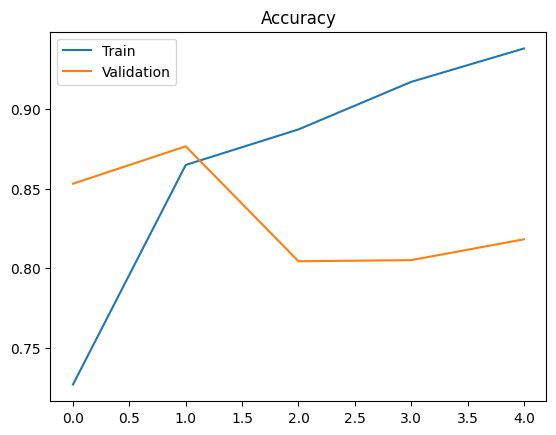

In [ ]:
#Plot Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title("Accuracy")
plt.show()

In [ ]:
#Task 8 — Evaluation
from sklearn.metrics import confusion_matrix, precision_score, recall_score

y_pred = (model.predict(X_test) > 0.5).astype(int)

print("Accuracy:", model.evaluate(X_test, y_test)[1])
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8181 - loss: 0.5079
Accuracy: 0.8180999755859375
Confusion Matrix:
 [[4013  948]
 [ 871 4168]]
Precision: 0.8146989835809226
Recall: 0.8271482436991466


In [ ]:
#Misclassified Reviews
for i in range(10):
    if y_test.iloc[i] != y_pred[i]:
        print(df['review'].iloc[i])

I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue is witty and the characters are likable (even the well bread suspected serial killer). While some may be disappointed when they realize this is not Match Point 2: Risk Addiction, I thought it was proof that Woody Allen is still fully in control of the style many of us have grown to love.<br /><br />This was the most I'd laughed at one of Woody's comedies in years (dare I say a decade?). While I've never been impressed with Scarlet Johanson, in this she managed to tone down her "sexy" image and jumped right into a average, but spirited young woman.<br /><br />This may not be the crown jewel of his career, but it was wittier than "Devil Wears Prada" and more interesting than "Superman" a great comedy to go see with friends.
This show was an amazing, fresh & innovative idea in the 70's when it fir

In [ ]:
#Task 9 — Real-Time Prediction
def predict_review(text):
    text = preprocess(text)
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=max_len)

    prob = model.predict(pad)[0][0]
    sentiment = "Positive" if prob > 0.5 else "Negative"

    print("Review:", text)
    print("Sentiment:", sentiment)
    print("Confidence:", round(float(prob), 2))
    print("-"*50)
# Test Examples
predict_review("This movie is amazing!")
predict_review("Worst product ever")
predict_review("Not bad but could be better")
predict_review("Absolutely fantastic experience")
predict_review("I hate this item")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Review: movie amazing
Sentiment: Positive
Confidence: 1.0
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Review: worst product ever
Sentiment: Negative
Confidence: 0.26
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Review: bad could better
Sentiment: Negative
Confidence: 0.16
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Review: absolutely fantastic experience
Sentiment: Positive
Confidence: 0.88
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Review: hate item
Sentiment: Positive
Confidence: 0.99
--------------------------------------------------
